In [1]:
import pandas as pd

file_path = "/content/drive/MyDrive/dataset/Wednesday-workingHours.pcap_ISCX.csv"  # change to your path
df = pd.read_csv(file_path)
print("Loaded shape:", df.shape)
df.head()

Loaded shape: (692703, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [2]:

# keep label aside if present for evaluation later
label_col = None
for c in df.columns:
    if c.strip().lower() == 'label':
        label_col = c
        break

labels = df[label_col].copy() if label_col else None
X = df.drop(columns=[label_col]) if label_col else df.copy()

# drop obvious non-feature cols (FlowID, IP, timestamps) if present
drop_cols = [c for c in X.columns if 'flow' in c.lower() or 'ip' in c.lower() or 'time' in c.lower()]
X = X.drop(columns=drop_cols, errors='ignore')
print("Feature matrix shape:", X.shape)

Feature matrix shape: (692703, 67)


In [3]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
#K-Means clustering and anomaly flagging
from sklearn.cluster import KMeans
import numpy as np

k = 3   # we can also try 2, 3, or 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Compute distance of each sample from its cluster center
distances = np.linalg.norm(X_scaled - kmeans.cluster_centers_[kmeans.labels_], axis=1)

# Use 97th percentile as anomaly cutoff instead of 95th
threshold_pct = 97
threshold = np.percentile(distances, threshold_pct)

# Flag anomalies
kmeans_flag = (distances > threshold).astype(int)   # 1 = anomaly

# Add results
df['KMeans_Anomaly'] = kmeans_flag
df['KMeans_Distance'] = distances

print("KMeans anomalies:", kmeans_flag.sum())

KMeans anomalies: 20782


In [5]:
#IsolationForest(i use this isolation forest)
from sklearn.ensemble import IsolationForest
iso = IsolationForest(random_state=42)
iso.fit(X_scaled)

iso_pred = iso.predict(X_scaled)  # -1 anomaly, 1 normal
iso_flag = (iso_pred == -1).astype(int)
df['Iso_Anomaly'] = iso_flag
df['Iso_Score'] = iso.decision_function(X_scaled)
print("IsolationForest anomalies:", iso_flag.sum())


IsolationForest anomalies: 56423


/tmp/ipython-input-2407731358.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=methods, y=counts, palette='muted')


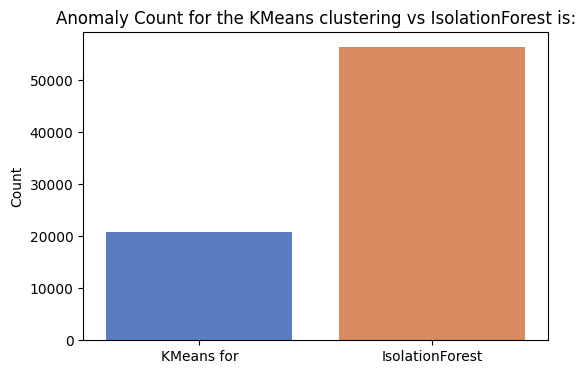

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
methods = ['KMeans for', 'IsolationForest']
counts = [df['KMeans_Anomaly'].sum(), df['Iso_Anomaly'].sum()]
sns.barplot(x=methods, y=counts, palette='muted')
plt.title("Anomaly Count for the KMeans clustering vs IsolationForest is:")
plt.ylabel("Count")
plt.show()


In [7]:
# showing top anomailes flow
top_iso = df.sort_values('Iso_Score').head(20)    # lowest scores means most anomalous
top_iso[['Iso_Score','Iso_Anomaly','KMeans_Anomaly'] + list(X.columns)[:8]]

,Iso_Score,Iso_Anomaly,KMeans_Anomaly,Destination Port,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean
426445,-0.264847,1,1,80,252,402,368861,458133,8311,6,1463.734127
459882,-0.257296,1,1,443,435,423,609185,38016,11658,6,1400.425287
450431,-0.256934,1,1,443,368,370,673750,27754,13298,6,1830.842391
65726,-0.256699,1,1,80,262,456,430492,443804,8994,6,1643.099237
457251,-0.254888,1,1,443,400,440,820328,29029,14578,6,2050.820000
454044,-0.253716,1,1,443,461,470,763814,37172,14578,6,1656.863341
467548,-0.247565,1,1,443,95,109,220007,5756,11658,6,2315.863158
273601,-0.247493,1,1,443,2765,3819,83756,8425267,950,0,30.291501
424035,-0.246629,1,1,80,268,430,407523,468399,8423,0,1520.608209
59440,-0.243706,1,1,80,177,303,266312,306310,5840,6,1504.587571


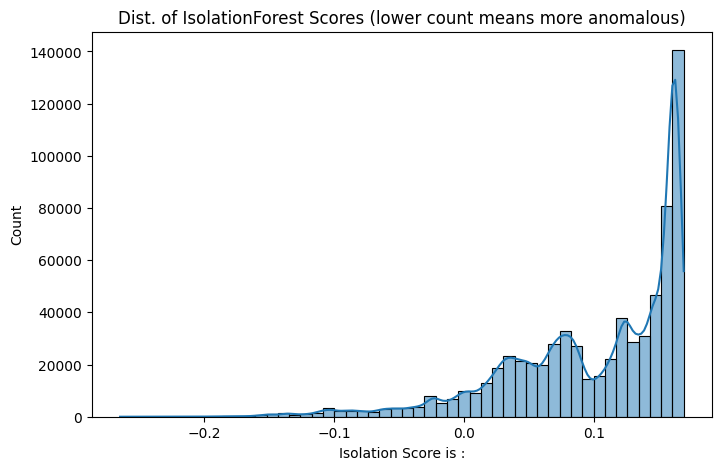

In [8]:
# now the distribution of isolation forest
plt.figure(figsize=(8,5))
sns.histplot(df['Iso_Score'], bins=50, kde=True)
plt.title("Dist. of IsolationForest Scores (lower count means more anomalous)")
plt.xlabel("Isolation Score is :"); plt.ylabel("Count")
plt.show()

In [9]:
#which features are different:
anoms = df[df['Iso_Anomaly']==1]
norms = df[df['Iso_Anomaly']==0]
feature_diff = pd.DataFrame({
    'feature': X.columns,
    'normal_mean': norms[X.columns].mean().values,
    'anomaly_mean': anoms[X.columns].mean().values
})
feature_diff['abs_diff'] = (feature_diff['anomaly_mean'] - feature_diff['normal_mean']).abs()
feature_diff.sort_values('abs_diff', ascending=False).head(10)

,feature,normal_mean,anomaly_mean,abs_diff
13,Fwd IAT Total,2.296797e+07,8.161244e+07,5.864447e+07
18,Bwd IAT Total,9.131115e+06,6.723737e+07,5.810625e+07
21,Bwd IAT Max,6.235481e+06,4.392334e+07,3.768786e+07
16,Fwd IAT Max,1.999468e+07,5.441549e+07,3.442081e+07
65,Idle Max,1.972393e+07,5.407253e+07,3.434860e+07
63,Idle Mean,1.961117e+07,5.030417e+07,3.069300e+07
66,Idle Min,1.947806e+07,4.717082e+07,2.769276e+07
19,Bwd IAT Mean,1.291842e+06,1.792989e+07,1.663805e+07
14,Fwd IAT Mean,3.833372e+06,1.900666e+07,1.517329e+07
20,Bwd IAT Std,2.531490e+06,1.470277e+07,1.217128e+07


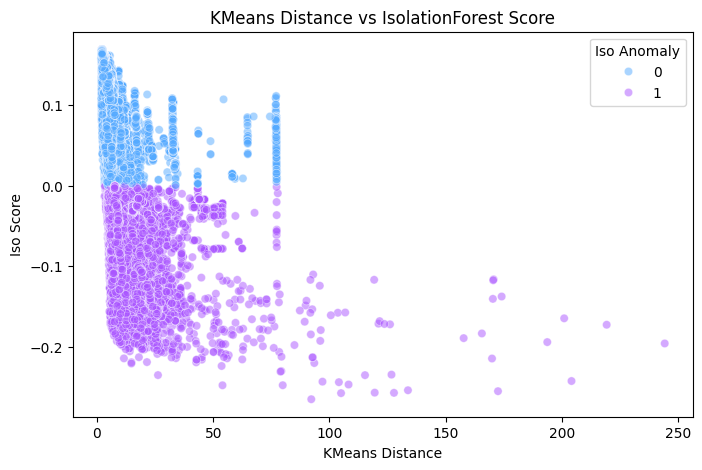

In [12]:
# visulaize the anomaly
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['KMeans_Distance'], y=df['Iso_Score'], hue=df['Iso_Anomaly'], alpha=0.5, palette='cool')
plt.title("KMeans Distance vs IsolationForest Score")
plt.xlabel("KMeans Distance"); plt.ylabel("Iso Score")
plt.legend(title="Iso Anomaly")
plt.show()

In [13]:
# comparing the both model flagged how many anomalies
both = df[(df['Iso_Anomaly']==1) & (df['KMeans_Anomaly']==1)]
print("Both models flagged:", len(both))

Both models flagged: 18810


In [14]:
# checking model performance
from sklearn.metrics import classification_report
import pandas as pd
# Convert label strings to binary (0 = Normal, 1 = Attack)
y_true = labels.astype(str).str.lower().apply(lambda x: 0 if 'benign' in x or 'normal' in x else 1).astype(int)
# Generate reports as dictionaries
iso_report = classification_report(y_true, df['Iso_Anomaly'], output_dict=True)
kmeans_report = classification_report(y_true, df['KMeans_Anomaly'], output_dict=True)
# Convert to DataFrames for better visualization
iso_df = pd.DataFrame(iso_report).transpose()
kmeans_df = pd.DataFrame(kmeans_report).transpose()
# Round values for readability
iso_df = iso_df.round(3)
kmeans_df = kmeans_df.round(3)
print("Isolation Forest Classification Report:")
display(iso_df)
print("\nK-Means Classification Report:")
display(kmeans_df)

Isolation Forest Classification Report:


,precision,recall,f1-score,support
0,0.640,0.925,0.756,440031.000
1,0.413,0.092,0.151,252672.000
accuracy,0.621,0.621,0.621,0.621
macro avg,0.526,0.508,0.453,692703.000
weighted avg,0.557,0.621,0.535,692703.000



K-Means Classification Report:


,precision,recall,f1-score,support
0,0.637,0.973,0.770,440031.000
1,0.424,0.035,0.064,252672.000
accuracy,0.631,0.631,0.631,0.631
macro avg,0.530,0.504,0.417,692703.000
weighted avg,0.559,0.631,0.513,692703.000


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
sns.set_style("whitegrid")

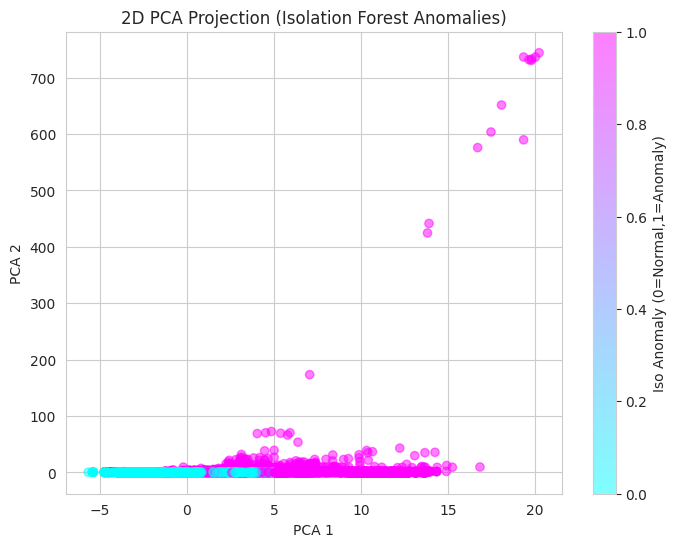

In [17]:
#pca visualization
pca = PCA(n_components=2)
proj = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(proj[:,0], proj[:,1], c=df['Iso_Anomaly'], cmap='cool', alpha=0.5)
plt.title("2D PCA Projection (Isolation Forest Anomalies)")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.colorbar(label="Iso Anomaly (0=Normal,1=Anomaly)")
plt.show()

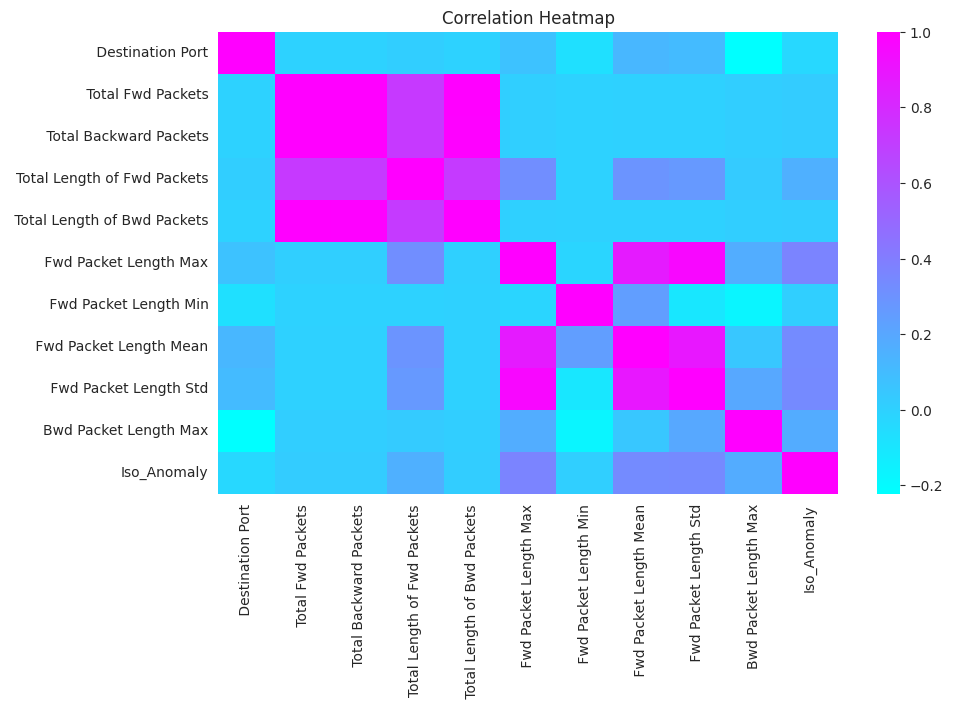

In [18]:
#checking corelation heatmap
top_features = feature_diff['feature'].head(10).tolist()
if len(top_features) > 1:
    plt.figure(figsize=(10,6))
    sns.heatmap(df[top_features + ['Iso_Anomaly']].corr(), annot=False, cmap='cool')
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("Not enough top features for heatmap.")

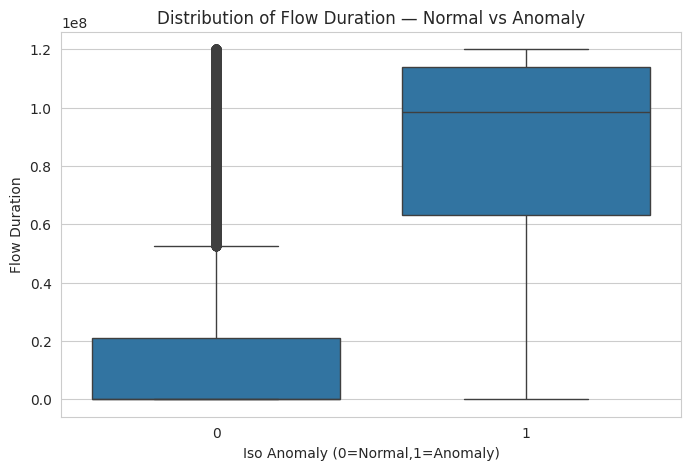

In [19]:
#feature distribution plotbox
feat = ' Flow Duration'
if feat in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Iso_Anomaly', y=feat, data=df)
    plt.title(f"Distribution of {feat.strip()} — Normal vs Anomaly")
    plt.xlabel("Iso Anomaly (0=Normal,1=Anomaly)")
    plt.ylabel(feat.strip())
    plt.show()
else:
    print(f"Column {feat} not found")

In [20]:
#saving all processed data
out = "/content/drive/MyDrive/dataset/Week5_AnomalyDetection_Results_isolationforest.csv"
df.to_csv(out, index=False)
print("Saved:", out)


Saved: /content/drive/MyDrive/dataset/Week5_AnomalyDetection_Results_isolationforest.csv


For the Week 6 of the AI Sentinal Assessment for Infosys Springboard

In [24]:
import pandas as pd

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/dataset/Wednesday-workingHours.pcap_ISCX.csv")

# Show all column names
print("Columns in your dataset:\n")
print(df.columns.tolist())

# Show first few rows (to inspect target-like column)
print("\nSample data:\n")
print(df.head())


Columns in your dataset:

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' AC

In [28]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np

# Step 1: Load dataset
df = pd.read_csv("/content/drive/MyDrive/dataset/Wednesday-workingHours.pcap_ISCX.csv")

# Step 2: Strip extra spaces from column names
df.columns = df.columns.str.strip()

# Step 3: Define target column
target_col = 'Label'

# Step 4: Encode target if it's categorical (BENIGN / ATTACK etc.)
if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].astype('category').cat.codes

# Step 5: Replace inf/-inf with NaN and fill with median (safe normalization)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# Step 6: Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Step 7: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8: Train Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 9: Get top 10 feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)
top10_features = importances.sort_values(ascending=False).head(10)

print("\nTop 10 Important Features:")
print(top10_features)

# Step 10: Create new dataframe with top 10 + label
df_top10 = df[top10_features.index.tolist() + [target_col]]

# Step 11: Save to CSV
df_top10.to_csv("/content/drive/MyDrive/dataset/Top10_Selected_Features.csv", index=False)

print("\nCleaned and saved successfully as 'Top10_Selected_Features.csv'")



Top 10 Important Features:
Max Packet Length         0.077651
Avg Bwd Segment Size      0.068575
Bwd Packet Length Max     0.067008
Average Packet Size       0.056431
Packet Length Variance    0.042108
Destination Port          0.041208
Bwd Packet Length Std     0.040943
Packet Length Std         0.039680
Packet Length Mean        0.039025
Bwd Packets/s             0.030665
dtype: float64

Cleaned and saved successfully as 'Top10_Selected_Features.csv'


In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from joblib import load
warnings.filterwarnings("ignore")

# Load the same dataset
data = pd.read_csv('/content/drive/MyDrive/dataset/Top10_Selected_Features.csv')

target_col = 'Label'
X = data.drop(columns=[target_col])
y = data[target_col]

#Stratified split ensures class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 🧾 Print dataset shapes
print("=== Dataset Shapes ===")
print(f"Full dataset shape   : {data.shape}")
print(f"Training set shape   : {X_train.shape} (Features), {y_train.shape} (Target)")
print(f"Testing set shape    : {X_test.shape} (Features), {y_test.shape} (Target)")
print("\nDataset Loaded Successfully for Week 6 Evaluation")

=== Dataset Shapes ===
Full dataset shape   : (692703, 11)
Training set shape   : (554162, 10) (Features), (554162,) (Target)
Testing set shape    : (138541, 10) (Features), (138541,) (Target)

Dataset Loaded Successfully for Week 6 Evaluation
